# Diffusion Tutorial

## What is diffusion?

Diffusion is a method of generatively modeling data that has become extremely popular over the last few years, within images, audio, video and computational biology to list a few examples. 

The key concept behind diffusion is the idea of **denoising**. Take images. The model is trained to reconstruct a clear image from a noised image. During training, this idea is simple - add noise to some input image and train the model to reconstruct the input image. But during inference, what we actually do is simply sample random noise, and get the model to create an entirely new image from that noise.

## In this tutorial

I am first going to go into training a simple *unconditional* image diffusion model using the diffusers library. An unconditional image diffusion model is one that creates images from random noise without any further information or guidance. Next, I will explain how to extend this model into a conditional model.

First, some imports and functional work.

In [36]:
%pip install datasets diffusers torch accelerate torchvision matplotlib transformers


[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [37]:
# uncomment the following line to write a default config file for accelerate, which is required for this tutorial.
# however, it would be better practice to run `accelerate config` in the terminal

# from accelerate.utils import write_basic_config

# write_basic_config()

In [38]:
import torch

if torch.cuda.is_available():
  print("Using CUDA")
  device = "cuda"
else:
  print('Using CPU')
  device = "cpu"

Using CUDA


## The dataset

I am using a dataset of celebrity faces. That means, you guessed it, the diffusion model at the end will be trying to make faces, and so we're going to get some lovely David Lynch-inspired stuff our model will put out in the meantime before we get there.

In [39]:
from datasets import load_dataset

dataset = load_dataset("irodkin/celeba_with_llava_shorter_captions")["train"]

Let's take a look at the dataset

In [40]:
dataset[0]['text']

'The image features a young woman with a round face, large eyes, and a smile. She has a small nose, thin lips, and a wide mouth, giving her an oval facial shape. Her eyes are brown, and she is wearing a blue dress. The woman is not wearing any visible accessories, and her facial hair is not described. However, she appears to be a young adult or a young woman.'

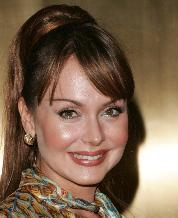

In [41]:
dataset[0]['image']

What does this look like numerically?

In [42]:
import numpy as np

np.array(dataset[0]['image'].convert('RGB'))

array([[[ 94,  75,  45],
        [ 93,  74,  44],
        [ 93,  74,  44],
        ...,
        [ 82,  66,  43],
        [ 80,  64,  39],
        [ 80,  64,  39]],

       [[ 95,  76,  46],
        [ 94,  75,  45],
        [ 94,  75,  45],
        ...,
        [ 83,  67,  44],
        [ 82,  66,  41],
        [ 82,  66,  41]],

       [[ 96,  77,  47],
        [ 96,  77,  47],
        [ 95,  76,  46],
        ...,
        [ 83,  67,  44],
        [ 81,  65,  40],
        [ 81,  65,  39]],

       ...,

       [[164, 126, 103],
        [134, 100,  72],
        [134, 110,  74],
        ...,
        [181, 158, 114],
        [178, 156, 107],
        [178, 156, 106]],

       [[179, 144, 125],
        [161, 131, 107],
        [165, 142, 110],
        ...,
        [182, 159, 115],
        [177, 155, 106],
        [177, 155, 105]],

       [[175, 142, 125],
        [158, 130, 108],
        [164, 143, 114],
        ...,
        [182, 159, 115],
        [177, 155, 106],
        [177, 155, 105]]

Each pixel is represented from 0-255 in RGB. This isn't statistically ideal to train on, so standard practice means normalising this to between -1 and 1. To artificially create a bit more training data, there's also a prewritten functionality we can rely on which will flip some proportion of the dataset.

In [43]:
image_dimension = 32

In [44]:
from torchvision import transforms
import re

image_preprocessor = transforms.Compose([
    transforms.Resize((image_dimension, image_dimension)), # this converts the image to have the dimensions we want
    transforms.ToTensor(), # this converts the image to a tensor and normalizes it to be between 0 and 1
    transforms.Normalize(0.5, 0.5), # this normalizes the image to be between -1 and 1
    transforms.RandomHorizontalFlip(), # this creates new images by flipping some examples horizontally
]
)

def preprocess(ds):
    ds['images'] = image_preprocessor(ds['image'].convert('RGB'))
    return ds

dataset = dataset.map(preprocess, remove_columns=['image', 'conditioning_image'], num_proc=8)
dataset.set_format('torch', ['images'], output_all_columns=True)

In [45]:
dataset = dataset.train_test_split(test_size=0.05, shuffle=True, seed=42)
train_dataset, val_dataset = dataset['train'], dataset['test']

So, now our dataset is preprocessed lets put it into a torch dataloader and move on.

In [46]:
import torch

train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=128, shuffle=True)
val_dataloader = torch.utils.data.DataLoader(val_dataset, batch_size=128, shuffle=False)

In [47]:
next(iter(train_dataloader))['images'].shape

torch.Size([128, 3, 32, 32])

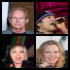

In [48]:
from utils import create_image_grid, save_image, save_losses

test = next(iter(train_dataloader))
test_images = test['images'][:4]
create_image_grid(test_images)

## The model

Diffusion models are most frequently UNets. A UNet is a model that funnels an image down multiple convolutional layers, slowly compressing the model along the width and height dimension and adding feature channels. Then, the funnel inverts, expanding along width and height dimension and compressing the feature channels, returning to the original 3 colour channels and pixel width/height the model had originally. In our case the final representation is a predicted amount of added noise for each pixel and colour dimension. See the below diagram for a example visualisation of what this looks like (although this example shows input channels as 1 and output as 2). 

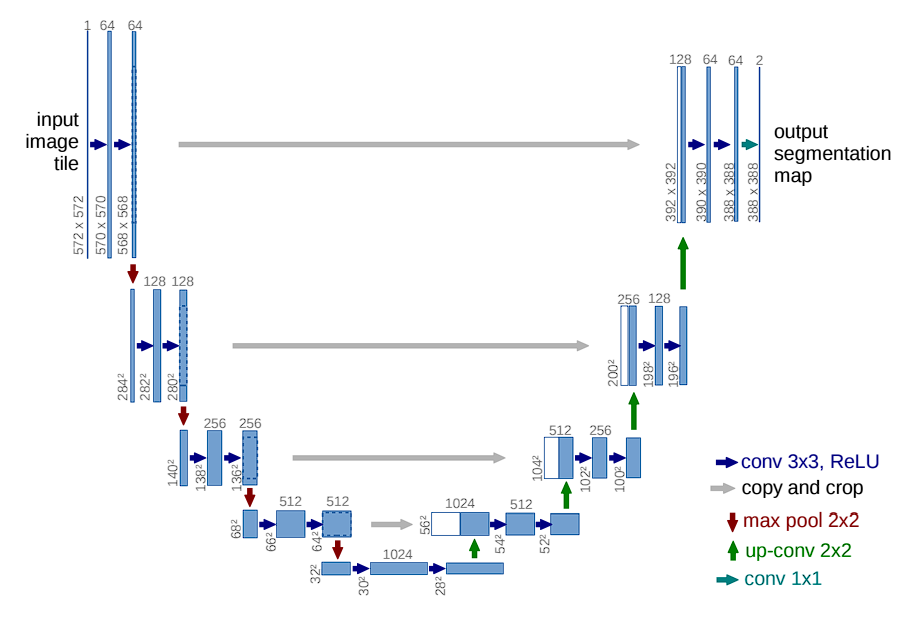

In [49]:
# credit to https://viso.ai/deep-learning/u-net-a-comprehensive-guide-to-its-architecture-and-applications/

from IPython.display import Image
Image(filename='resources/uNet-architecture.png') 

The implementation of this is below. The variables invoked are:

- down_block_types/up_block_types: explains how the model is going up and down channels
- in_channels/out_channels: the number of channels we take in and come out of the model
- sample size: the size of the image (variable height and width can be entered as a tuple)

In [50]:
from diffusers import UNet2DModel


denoiser = UNet2DModel(
    sample_size=image_dimension,
    in_channels=3,
    out_channels=3,
    down_block_types=[
        "DownBlock2D",
        "DownBlock2D",
        "AttnDownBlock2D",
        "AttnDownBlock2D"
    ],
    up_block_types=[
        "AttnUpBlock2D",
        "AttnUpBlock2D",
        "UpBlock2D",
        "UpBlock2D"
    ],
    block_out_channels=(64, 128, 128, 128),
)

denoiser

UNet2DModel(
  (conv_in): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (time_proj): Timesteps()
  (time_embedding): TimestepEmbedding(
    (linear_1): Linear(in_features=64, out_features=256, bias=True)
    (act): SiLU()
    (linear_2): Linear(in_features=256, out_features=256, bias=True)
  )
  (down_blocks): ModuleList(
    (0): DownBlock2D(
      (resnets): ModuleList(
        (0-1): 2 x ResnetBlock2D(
          (norm1): GroupNorm(32, 64, eps=1e-05, affine=True)
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (time_emb_proj): Linear(in_features=256, out_features=64, bias=True)
          (norm2): GroupNorm(32, 64, eps=1e-05, affine=True)
          (dropout): Dropout(p=0.0, inplace=False)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (nonlinearity): SiLU()
        )
      )
      (downsamplers): ModuleList(
        (0): Downsample2D(
          (conv): Conv2d(64, 64, ker

## The scheduler

I have been a bit simplistic so far. While, for each forward pass, the model *does* try and predict the distance between the noised image and the original image, in actuality when noising and denoising an image we apply/remove noise **iteratively**. This means we noise/denoise over a series of timesteps, where timestep 0 is the denoised image and timestep T is the image with all the iterative noise added to it. For noising, this means at each timestep, the image we create is a weighted linear combination of our previous image and some amount of noise. What the weights are, depends on the timestep. For example, the amount of noise we add to the raw image at the start of the noising process is usually very small, and gets larger with later timesteps. The way the weighted sum of noise and image changes with each timestep is called the beta schedule. In the diffusers library, the way this is implemented is through a scheduler class. The most simple, which we will start with, is the DDPM scheduler.

In [51]:
from diffusers import DDPMScheduler

num_train_timesteps = 1000

scheduler = DDPMScheduler(beta_schedule='scaled_linear', num_train_timesteps=num_train_timesteps)

Now let's initialise some more familiar components. For the optimizer, AdamW works perfectly well. The loss function is the mean-squared error between the amount of noise we predicted and the noise that was actually added.

In [52]:
from torch.optim import AdamW
from torch.nn import MSELoss

criterion = MSELoss()

optimizer = AdamW(denoiser.parameters(), lr=1e-4)
optimizer

AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0.01
)

## Training and inference functions

With a given model the steps for inference are this:

1. Generate a random sample of data, call it X.
2. Do a forward pass through the model with X to generate a noise prediction N.
3. Use N along with the current timestep (starting at T and ending at 0) to find the amount of noise N_t we ought to subtract from X
4. Update X to be X - N_t
5. Repeat 2-4 until timestep 0

In [53]:
from tqdm import tqdm

def inference(noise, model, scheduler):
    model.eval()

    current_noise = torch.clone(noise)

    with torch.no_grad():
        for step in tqdm(scheduler.timesteps):
            noise_pred = model(current_noise, step).sample
            current_noise = scheduler.step(noise_pred, step, current_noise).prev_sample

    generated_images = current_noise
    return generated_images

And to train the model, we:

1. Get an image, and sample some random noise to add to the image.
2. Sample a timestep somewhere in the range of timesteps the scheduler operates over.
3. Combine the noise and image together in a weighted sum, where the weights are specified by the sampled timestep.
4. Do a forward pass through the model with the noised image and get a prediction of the noise.
5. Calculate the MSE between the predicted noise and true noise and update model accordingly.

In [54]:
def train_step(model, optimizer, scheduler, accelerator, images):
    model.train()
    noise = torch.randn(images.shape, device=device)
    bs = images.shape[0]

    timesteps = torch.randint(0, num_train_timesteps - 1, (bs,), device=device, dtype=torch.long)
    noisy_images = scheduler.add_noise(images, noise, timesteps)

    predicted_noise = model(noisy_images, timesteps).sample

    loss = criterion(predicted_noise, noise)
    accelerator.backward(loss)
    optimizer.step()
    optimizer.zero_grad()

    return loss.item()


In [55]:
def val_step(model, scheduler, images):
    model.eval()

    noise = torch.randn(images.shape, device=device)
    bs = images.shape[0]

    timesteps = torch.randint(0, num_train_timesteps - 1, (bs,), device=device, dtype=torch.long)
    noisy_images = scheduler.add_noise(images, noise, timesteps)

    with torch.no_grad():
        predicted_noise = model(noisy_images, timesteps).sample

    loss = criterion(predicted_noise, noise)

    return loss.item()

### First training run

The below function runs the training and inference function every epoch, and logs the average losses over the epoch.

In [56]:
from tqdm import tqdm

import accelerate

accelerator = accelerate.Accelerator()

def training_loop(model, optimizer, train_dataloader, val_dataloader, scheduler, accelerator, num_epochs):

    model.train()

    eval_set = torch.randn(4, 3, image_dimension, image_dimension).to(device)

    for epoch in range(num_epochs):

        train_losses = []
        val_losses = []
        model.train()

        for batch in tqdm(train_dataloader):
            images = batch['images'].to(device)
            loss = train_step(model, optimizer, scheduler, accelerator, images)
            train_losses.append(loss)

        for batch in tqdm(val_dataloader):
            images = batch['images'].to(device)
            loss = val_step(model, scheduler, images)
            val_losses.append(loss)

        mean_train_loss = np.mean(train_losses)
        mean_val_loss = np.mean(val_losses)
        generated_images = inference(eval_set, model, scheduler)
        save_image(generated_images, f'outputs/little_freaks/epoch_{epoch}.png')
        save_losses(train_losses, f'outputs/little_freaks/train_losses_{epoch}.png')
        save_losses(val_losses, f'outputs/little_freaks/val_losses_{epoch}.png')
        print(f'Epoch {epoch} \nTrain loss: {mean_train_loss.item()} \nVal loss: {mean_val_loss.item()}')

In [57]:

denoiser, optimizer, train_dataloader, val_dataloader, scheduler = accelerator.prepare(denoiser, optimizer, train_dataloader, val_dataloader, scheduler)

Launching training on one GPU.


100%|██████████| 1000/1000 [00:30<00:00, 32.77it/s]


Epoch 0 
Train loss: 0.15023198960969844 
Val loss: 0.0799143947660923


100%|██████████| 1000/1000 [00:32<00:00, 31.11it/s]


Epoch 1 
Train loss: 0.07007475809504589 
Val loss: 0.06342471786774695


...

Epoch 7 
Train loss: 0.04953746368487676 
Val loss: 0.04986932035535574


100%|██████████| 1000/1000 [00:35<00:00, 28.43it/s]


Epoch 8 
Train loss: 0.048710280482967695 
Val loss: 0.04762757197022438


100%|██████████| 1000/1000 [00:35<00:00, 28.50it/s]


Epoch 9 
Train loss: 0.04893974253286918 
Val loss: 0.0482705170288682


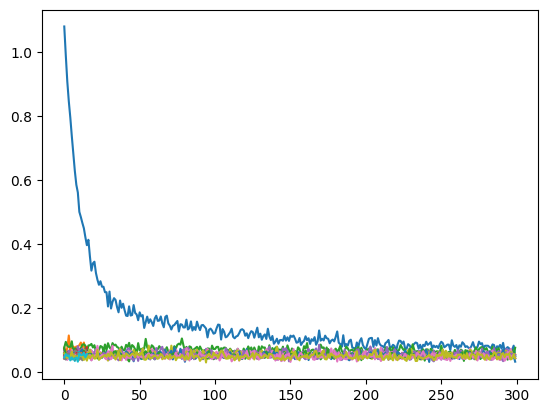

In [58]:
# training_loop(denoiser, optimizer, train_dataloader, scheduler, accelerator, 10)
accelerate.notebook_launcher(training_loop, args=(denoiser, optimizer, train_dataloader, val_dataloader, scheduler, accelerator, 10), num_processes=1, mixed_precision="fp16")


This results in the following images after 10 epochs. Because I've only generated images sized 32x32, the results might be a little hard to see in detail within the notebook, but you can see that they are clearly people. 

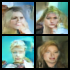

In [59]:
Image(filename='resources/unconditional_celebrity_model_small_10_epochs.png')

We have two tasks from here. The first is to generate good quality higher resolution images. This is a matter of scaling up the model and doing more training. The second more interesting - adding text conditioning.

Both of these I will be tackling as we go forward. Keep your eye on this repo in the coming weeks to see the tutorial updated to do this task.